_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: **Karim Zaghw, Kai Rothe, Mohammed Abbas Ansari**

LLM Disclaimer: Yes, ChatGPT and Copilot was used in almost all the cell blocks to produce code. Modifications was done to LLM's output and care was taken to ensure desired outcome. 

# Coding Lab 3

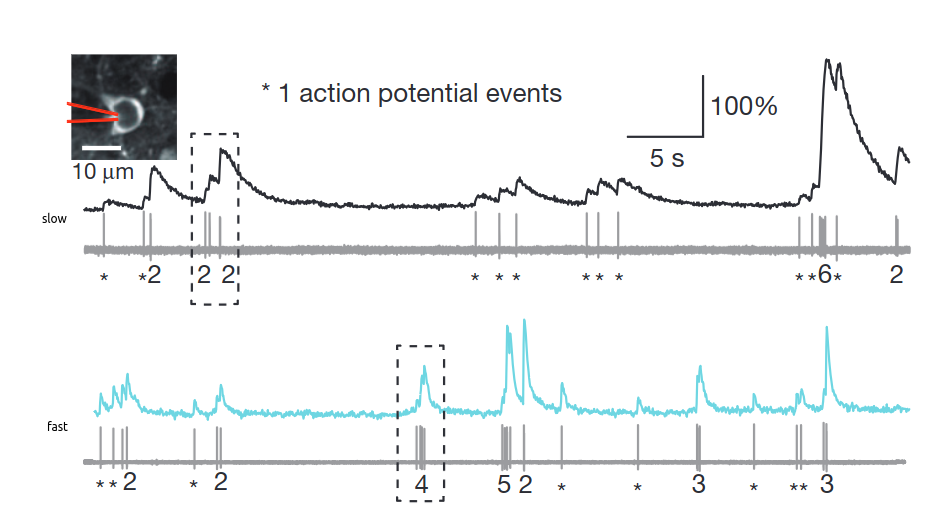

In this notebook you will work with 2 photon calcium recordings from mouse V1 and retina. For details see [Chen et al. 2013](https://www.nature.com/articles/nature12354) and [Theis et al. 2016](https://www.cell.com/neuron/pdf/S0896-6273(16)30073-3.pdf). Two-photon imaging is widely used to study computations in populations of neurons. 

In this exercise sheet we will study properties of different indicators and work on methods to infer spikes from calcium traces. All data is provided at a sampling rate of 100 Hz. For easier analysis, please resample it to 25 Hz. `scipy.signal.decimate` can help here, but note that it is only meant for continous signals. 

__Data__: Download the data file ```nds_cl_3_*.csv``` from ILIAS and save it in a subfolder ```../data/```. Note, some recordings were of shorter duration, hence their columns are padded. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import signal
from scipy.signal import decimate, butter, filtfilt
from __future__ import annotations

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2025-05-11 21:56:45CEST

Python implementation: CPython
Python version       : 3.9.6
IPython version      : 8.18.1

sklearn: 1.5.2

seaborn   : 0.13.2
matplotlib: 3.9.2
pandas    : 2.2.3
scipy     : 1.13.1
numpy     : 2.0.2

Watermark: 2.5.0



In [2]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [3]:
# ogb dataset from Theis et al. 2016 Neuron
ogb_calcium = pd.read_csv("../data/nds_cl_3_ogb_calcium.csv", header=0)
ogb_spikes = pd.read_csv("../data/nds_cl_3_ogb_spikes.csv", header=0)
print(f"[OGB] calcium: {ogb_calcium.shape}, spikes: {ogb_spikes.shape}")

# gcamp dataset from Chen et al. 2013 Nature
gcamp_calcium = pd.read_csv("../data/nds_cl_3_gcamp2_calcium.csv", header=0)
gcamp_spikes = pd.read_csv("../data/nds_cl_3_gcamp2_spikes.csv", header=0)
print(f"[GCaMP] calcium: {gcamp_calcium.shape}, spikes: {gcamp_spikes.shape}")

# spike dataframe
ogb_spikes.head()

[OGB] calcium: (71986, 11), spikes: (71986, 11)
[GCaMP] calcium: (23973, 37), spikes: (23973, 37)


,0,1,2,3,4,5,6,7,8,9,10
0,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
1,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
2,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
3,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
4,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0


## Task 1: Visualization of calcium and spike recordings

We start again by plotting the raw data - calcium and spike traces in this case. One dataset has been recorded using the synthetic calcium indicator OGB-1 at population imaging zoom (~100 cells in a field of view) and the other one using the genetically encoded indicator GCamp6f zooming in on individual cells. Plot the traces of an example cell from each dataset to show how spikes and calcium signals are related. A good example cell for the OGB-dataset is cell 5. For the CGamp-dataset a good example is cell 6. Align the traces by eye (add a small offset to the plot) such that a valid comparison is possible and zoom in on a small segment of tens of seconds.

*Grading: 3 pts*

In [4]:
factor = 4
fs_new = 100 // factor  # =25

In [5]:
def decimate_nonan(df, factor, ftype="fir", zero_phase=True):

    n_rows = df.shape[0]
    n_new = math.ceil(n_rows / factor)
    out = {}

    for col in df.columns:
        x = df[col].values

        nan_pos = np.where(np.isnan(x))[0]
        cutoff = nan_pos[0] if nan_pos.size > 0 else n_rows

        valid = x[:cutoff]
        if valid.size:
            y = decimate(valid, factor, axis=0, ftype=ftype, zero_phase=zero_phase)
        else:
            y = np.empty(0, dtype=float)

        pad_len = n_new - y.size
        if pad_len > 0:
            y = np.concatenate([y, np.full(pad_len, np.nan)])

        out[col] = y

    return pd.DataFrame(out)


ogb_cal_ds = decimate_nonan(ogb_calcium, factor)
gcamp_cal_ds = decimate_nonan(gcamp_calcium, factor)

In [6]:
def downsample_spikes(df, factor):

    n_rows, n_cols = df.shape
    n_blocks = math.ceil(n_rows / factor)
    total_len = n_blocks * factor

    vals = df.values
    pad_len = total_len - n_rows
    if pad_len > 0:
        pad = np.full((pad_len, n_cols), np.nan)
        vals = np.vstack([vals, pad])

    arr = vals.reshape(n_blocks, factor, n_cols)

    block_sums = np.nansum(arr, axis=1)
    non_nan_counts = np.sum(~np.isnan(arr), axis=1)

    block_sums[non_nan_counts == 0] = np.nan

    return pd.DataFrame(block_sums, columns=df.columns)


ogb_spk_ds = downsample_spikes(ogb_spikes, factor)
gcamp_spk_ds = downsample_spikes(gcamp_spikes, factor)

In [7]:
t = np.arange(len(ogb_cal_ds)) / fs_new

t_start, t_end = 10, 40
i0, i1 = int(t_start * fs_new), int(t_end * fs_new)

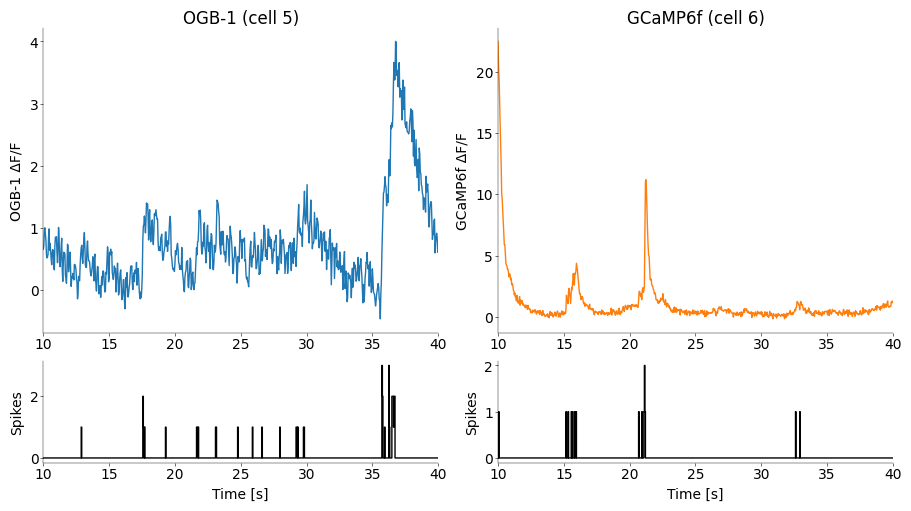

In [8]:
# --------------------------------
# Resample and prepare data (1 pt)
# --------------------------------

fig, axs = plt.subplots(
    2, 2, figsize=(9, 5), height_ratios=[3, 1], layout="constrained"
)
# --------------------
# Plot OGB data (1 pt)
# --------------------
cell_ogb = 4
cal_ogb = ogb_cal_ds.iloc[i0:i1, cell_ogb]
spk_ogb = ogb_spk_ds.iloc[i0:i1, cell_ogb]

# calcium
axs[0, 0].plot(t[i0:i1], cal_ogb, color="tab:blue")
axs[0, 0].set_ylabel("OGB-1 ΔF/F")
axs[0, 0].set_xlim(t_start, t_end)
axs[0, 0].set_title("OGB-1 (cell 5)")

# spikes
axs[1, 0].plot(t[i0:i1], spk_ogb, drawstyle="steps-post", color="k")
axs[1, 0].set_ylabel("Spikes")
axs[1, 0].set_xlabel("Time [s]")
axs[1, 0].set_xlim(t_start, t_end)


# ----------------------
# Plot GCamp data (1 pt)
# ----------------------

cell_gcamp = 5

cal_gcamp = gcamp_cal_ds.iloc[i0:i1, cell_gcamp]
spk_gcamp = gcamp_spk_ds.iloc[i0:i1, cell_gcamp]

# calcium
axs[0, 1].plot(t[i0:i1], cal_gcamp, color="tab:orange")
axs[0, 1].set_ylabel("GCaMP6f ΔF/F")
axs[0, 1].set_xlim(t_start, t_end)
axs[0, 1].set_title("GCaMP6f (cell 6)")

# spikes
axs[1, 1].plot(t[i0:i1], spk_gcamp, drawstyle="steps-post", color="k")
axs[1, 1].set_ylabel("Spikes")
axs[1, 1].set_xlabel("Time [s]")
axs[1, 1].set_xlim(t_start, t_end)

plt.show()

Shifting the spike signal was unnecessary, as the calcium and spike signals already appear well-aligned. The calcium signal clearly indicates likely spike events, which correspond closely to those in the recorded spike signal.

## Bonus Task (Optional): Calcium preprocessing

To improve the quality of the inferred spike trains, further preprocessing steps can undertaken. This includes filtering and smoothing of the calcium trace.

Implement a suitable filter and local averaging procedure as discussed in the lecture. Explain your choices and discuss how it helps!

_Grading: 1 BONUS point_

_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [9]:
def bandpass_filter_columnwise(df, lowcut, highcut, fs, order=2):
    b, a = butter(N=order, Wn=[lowcut, highcut], btype="band", fs=fs)
    padlen = 3 * max(len(a), len(b))

    filtered = {}
    for col in df.columns:
        x = df[col].values
        nan_idxs = np.where(np.isnan(x))[0]
        if nan_idxs.size > 0:
            m = nan_idxs[0]
            valid = x[:m]
            if valid.size > padlen:
                y_valid = filtfilt(b, a, valid)
            else:
                y_valid = np.full_like(valid, np.nan)
            y = np.concatenate([y_valid, np.full(x.size - valid.size, np.nan)])
        else:
            y = filtfilt(b, a, x)
        filtered[col] = y

    return pd.DataFrame(filtered, index=df.index)


def iterative_smoothing(trace, thr_noise=1.0, max_iter=5000):
    """Iterative smoothing procedure as described in Yaksi & Friedrich (2006).

    Parameters
    ----------
    trace : np.ndarray
        Input calcium trace (filtered).
    thr_noise : float
        Noise threshold for determining small peaks.
    max_iter : int
        Maximum number of iterations.

    Returns
    -------
    smoothed : np.ndarray
        Smoothed trace.
    """
    smoothed = trace.copy()
    for _ in range(max_iter):
        # Find all peaks
        peaks, _ = signal.find_peaks(smoothed)
        if len(peaks) < 3:
            break

        # Compute amplitudes relative to previous peak
        peak_amplitudes = smoothed[peaks]
        diffs = np.abs(np.diff(peak_amplitudes, prepend=peak_amplitudes[0]))

        # Find smallest peak (in terms of amplitude difference to previous)
        min_idx = np.argmin(diffs)
        if diffs[min_idx] >= thr_noise:
            break  # stop if all peaks are above noise threshold

        # Define bounds of smoothing region
        if min_idx == 0 or min_idx == len(peaks) - 1:
            continue  # skip if at boundary
        left = peaks[min_idx - 1]
        right = peaks[min_idx + 1]

        # Smooth segment between peaks
        segment = smoothed[left : right + 1]
        smoothed_segment = segment.copy()
        smoothed_segment[1:-1] = (segment[:-2] + segment[1:-1] + segment[2:]) / 3
        smoothed[left : right + 1] = smoothed_segment

    return smoothed

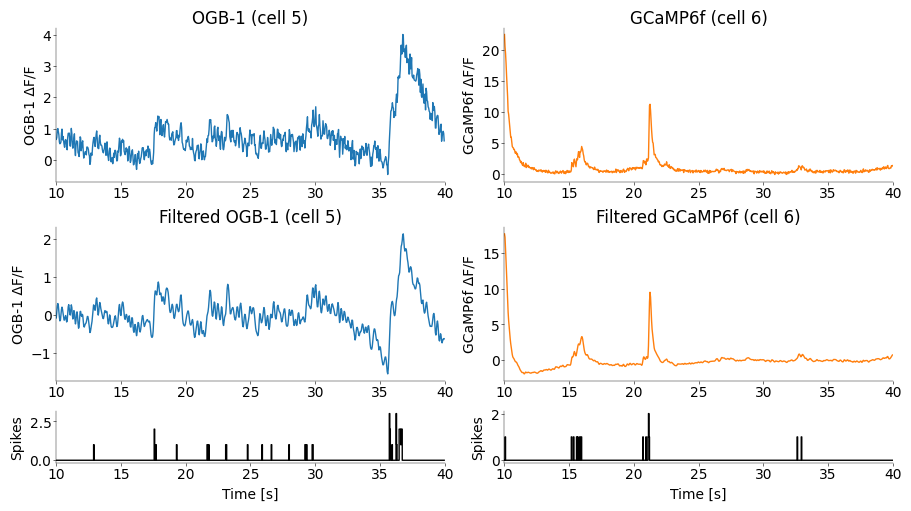

In [10]:
ogb_cal_filt_df = bandpass_filter_columnwise(ogb_cal_ds, 0.1, 5, fs_new)
gcamp_cal_filt_df = bandpass_filter_columnwise(gcamp_cal_ds, 0.1, 5, fs_new)

# iterative smoothing
for col in ogb_cal_filt_df.columns:
    ogb_cal_filt_df[col] = iterative_smoothing(
        ogb_cal_filt_df[col].values, thr_noise=5, max_iter=5000
    )
for col in gcamp_cal_filt_df.columns:
    gcamp_cal_filt_df[col] = iterative_smoothing(
        gcamp_cal_filt_df[col].values, thr_noise=5, max_iter=5000
    )


fig, axs = plt.subplots(
    3, 2, figsize=(9, 5), height_ratios=[3, 3, 1], layout="constrained"
)
# --------------------
# Plot OGB data (1 pt)
# --------------------

cal_ogb_filt = ogb_cal_filt_df.iloc[i0:i1, cell_ogb]

# calcium
axs[0, 0].plot(t[i0:i1], cal_ogb, color="tab:blue")
axs[0, 0].set_ylabel("OGB-1 ΔF/F")
axs[0, 0].set_xlim(t_start, t_end)
axs[0, 0].set_title("OGB-1 (cell 5)")

# calcium
axs[1, 0].plot(t[i0:i1], cal_ogb_filt, color="tab:blue")
axs[1, 0].set_ylabel("OGB-1 ΔF/F")
axs[1, 0].set_xlim(t_start, t_end)
axs[1, 0].set_title("Filtered OGB-1 (cell 5)")

# spikes
axs[2, 0].plot(t[i0:i1], spk_ogb, drawstyle="steps-post", color="k")
axs[2, 0].set_ylabel("Spikes")
axs[2, 0].set_xlabel("Time [s]")
axs[2, 0].set_xlim(t_start, t_end)


# ----------------------
# Plot GCamp data (1 pt)
# ----------------------

# calcium
axs[0, 1].plot(t[i0:i1], cal_gcamp, color="tab:orange")
axs[0, 1].set_ylabel("GCaMP6f ΔF/F")
axs[0, 1].set_xlim(t_start, t_end)
axs[0, 1].set_title("GCaMP6f (cell 6)")

cal_gcamp_filt = gcamp_cal_filt_df.iloc[i0:i1, cell_gcamp]

# calcium
axs[1, 1].plot(t[i0:i1], cal_gcamp_filt, color="tab:orange")
axs[1, 1].set_ylabel("GCaMP6f ΔF/F")
axs[1, 1].set_xlim(t_start, t_end)
axs[1, 1].set_title("Filtered GCaMP6f (cell 6)")

# spikes
axs[2, 1].plot(t[i0:i1], spk_gcamp, drawstyle="steps-post", color="k")
axs[2, 1].set_ylabel("Spikes")
axs[2, 1].set_xlabel("Time [s]")
axs[2, 1].set_xlim(t_start, t_end)

plt.show()

To improve the quality of deconvolved spike trains, we implemented the two-step preprocessing method as described in **Yaksi & Friedrich (2006)**:

**1. Butterworth Filtering**

We used a band-pass Butterworth filter with cutoff frequencies between 0.1 and 5. This step reduces high-frequency noise while preserving the sharp onset of calcium transients caused by action potentials.

**2. Iterative Local Averaging**

Inspired by Supplementary Figure 3 of the paper, we implemented an **iterative smoothing procedure** that identifies small peaks (amplitudes below a threshold, `thr_noise = 5.0`) and locally averages the trace between neighboring peaks. This step preserves high-amplitude spike-related signals while selectively smoothing out low-amplitude noise.

At each iteration:
- Peaks are detected.
- The peak with the smallest amplitude difference to the previous peak is identified.
- If this difference is less than `thr_noise`, the segment between its adjacent peaks is smoothed via local averaging.
- This process continues until either all such small peaks are smoothed or a maximum number of iterations (default 5000) is reached.

**Why this helps**

This method suppresses noise that might otherwise lead to spurious spikes during deconvolution. Unlike global smoothing (e.g., moving average), this approach **preserves temporal resolution** and **sharp transients**, improving the precision of spike inference.



## Task 2: Simple deconvolution

It is clear from the above plots that the calcium events happen in relationship to the spikes. As a first simple algorithm implement a deconvolution approach like presented in the lecture in the function `deconv_ca`. Assume an exponential kernel where the decay constant depends on the indicator ($\tau_{OGB}= 0.5 s$, $\tau_{GCaMP}= 0.1 s$). Note there can be no negative rates! Plot the kernel as well as an example cell with true and deconvolved spike rates. Scale the signals such as to facilitate comparisons. You can use functions from `scipy` for this. Explain your results and your choice of kernel.

*Grading: 6 pts*


In [11]:
# Normalize signals for comparison
def min_max_scale(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-10)


def scipy_deconv_ca(ca: np.ndarray, tau: float, dt: float) -> np.ndarray:
    """Compute the deconvolution of the calcium signal using scipy.

    Parameters
    ----------

    ca: np.array, (n_points,)
        Calcium trace

    tau: float
        decay constant of conv kernel

    dt: float
        sampling interval.

    Return
    ------

    sp_hat: np.array
    """

    # --------------------------------------------
    # apply devonvolution to calcium signal (1 pt)
    # --------------------------------------------

    # Create truncated exponential decay kernel: exp(-t / tau) truncated at t = 2*tau (per Yaksi & Friedrich)
    t_max = 2 * tau  # truncate kernel at 2 × tau
    t = np.arange(0, t_max, dt)
    kernel = np.exp(-t / tau)
    kernel /= kernel.sum()  # normalize kernel so it integrates to 1

    # Deconvolve:

    sp_hat, _ = signal.deconvolve(ca, kernel)

    # Enforce non-negative spike estimates (biological constraint)
    sp_hat = np.clip(sp_hat, 0, None)

    return sp_hat

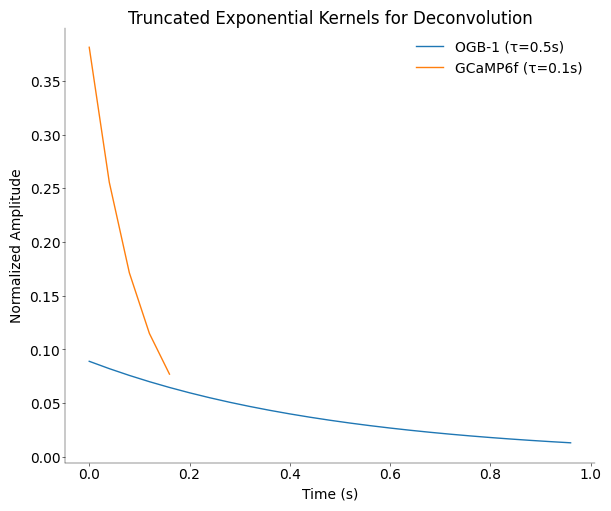

In [12]:
# -------------------------
# Plot the 2 kernels (1 pt)
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

# Parameters
dt = 1 / 25  # sampling interval at 25 Hz
tau_ogb = 0.5  # in seconds
tau_gcamp = 0.1  # in seconds

# Create time axes for truncated kernels (up to 2 * tau)
t_ogb = np.arange(0, 2 * tau_ogb, dt)
t_gcamp = np.arange(0, 2 * tau_gcamp, dt)

# Compute and normalize kernels
kernel_ogb = np.exp(-t_ogb / tau_ogb)
kernel_ogb /= kernel_ogb.sum()

kernel_gcamp = np.exp(-t_gcamp / tau_gcamp)
kernel_gcamp /= kernel_gcamp.sum()

# Plot the kernels
ax.plot(t_ogb, kernel_ogb, label="OGB-1 (τ=0.5s)")
ax.plot(t_gcamp, kernel_gcamp, label="GCaMP6f (τ=0.1s)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Amplitude")
ax.set_title("Truncated Exponential Kernels for Deconvolution")
ax.legend()
plt.show()

### Questions (1 pt)
1) Explain how you constructed the kernels

We modeled the calcium transient response as a truncated exponential decay function of the form `exp(-t / τ)`, where `τ` is the decay constant specific to the calcium indicator (0.5 s for OGB-1 and 0.1 s for GCaMP6f). Following the method described in Yaksi & Friedrich (2006), we truncated the kernel at `t = 2τ` to retain the meaningful portion of the transient while reducing computational complexity. We then normalized each kernel to ensure that the total area under the curve is 1, making the convolution energy-preserving and suitable for deconvolution.

---

2) How do the indicators / kernels compare?

- The **OGB-1** kernel has a slower decay ($\tau = 0.5$ s), meaning that its calcium signal persists longer after each spike.
- The **GCaMP6f** kernel has a much faster decay ($\tau = 0.1$ s), leading to sharper, more temporally localized calcium transients.

As a result, OGB-1 produces broader calcium signals, while GCaMP6f yields more precise, spike-like responses in time.

---

3) What are pros and cons of each indicator?

**OGB-1 (Synthetic dye):**  
*Pros*: Very fast kinetics, ideal for capturing rapid calcium transients. Good for population imaging (many cells at once)  
*Cons*: Slower decay blurs temporal details. Short-term use only; requires invasive loading and lacks cell-type specificity.

**GCaMP6f (Genetically encoded):**  
*Pros*: Fast decay enables better temporal precision. Enables long-term, cell-type-specific population imaging via genetic targeting.  
*Cons*: Lower signal-to-noise ratio. Slightly slower kinetics than synthetic dyes like OGB-1.

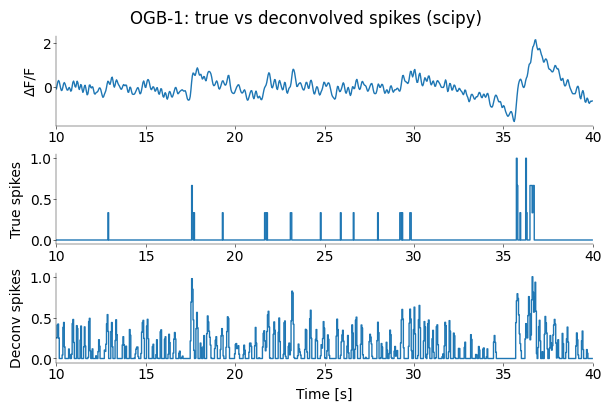

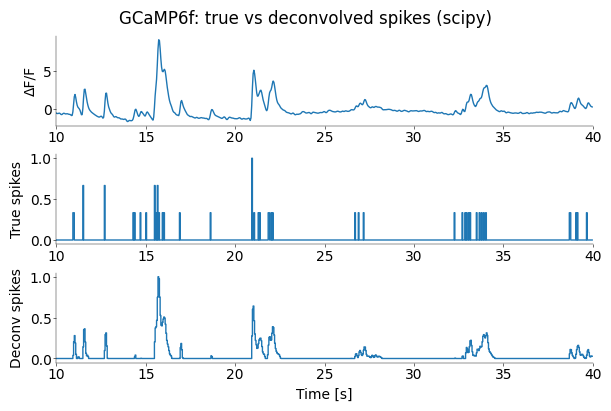

In [13]:
# ----------------------------------------------------------------------
# Compare true and deconvolved spikes rates for the OGB and GCamP cells.
# What do you notice? Why is that? (3 pts)
# ----------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell
ca_ogb = ogb_cal_filt_df.iloc[i0:i1, cell_ogb].values
spk_ogb = ogb_spk_ds.iloc[i0:i1, cell_ogb].values
spk_hat_ogb_full = scipy_deconv_ca(ogb_cal_filt_df.iloc[:, cell_ogb], tau_ogb, dt)
spk_hat_ogb = spk_hat_ogb_full[i0:i1]
t_seg = t[i0:i1]

# 1) Calcium trace
axs[0].plot(t_seg, ca_ogb)
axs[0].set_ylabel("ΔF/F")
axs[0].set_xlim(t_start, t_end)

# 2) True spike counts
axs[1].plot(t_seg, min_max_scale(spk_ogb), drawstyle="steps-post")
axs[1].set_ylabel("True spikes")
axs[1].set_xlim(t_start, t_end)

# 3) Deconvolved spike estimate
axs[2].plot(t_seg, min_max_scale(spk_hat_ogb), drawstyle="steps-post")
axs[2].set_ylabel("Deconv spikes")
axs[2].set_xlabel("Time [s]")
axs[2].set_xlim(t_start, t_end)

fig.suptitle("OGB-1: true vs deconvolved spikes (scipy)")
plt.show()


fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# GCamp Cell
cell_gcamp = 6
ca_gc = gcamp_cal_filt_df.iloc[i0:i1, cell_gcamp].values
spk_gc = gcamp_spk_ds.iloc[i0:i1, cell_gcamp].values
spk_hat_gc_full = scipy_deconv_ca(
    gcamp_cal_filt_df.iloc[:, cell_gcamp].values, tau_gcamp, dt
)
spk_hat_gc = spk_hat_gc_full[i0:i1]

# 1) Calcium trace
axs[0].plot(t_seg, ca_gc)
axs[0].set_ylabel("ΔF/F")
axs[0].set_xlim(t_start, t_end)

# 2) True spikes
axs[1].plot(t_seg, min_max_scale(spk_gc), drawstyle="steps-post")
axs[1].set_ylabel("True spikes")
axs[1].set_xlim(t_start, t_end)

# 3) Deconvolved spikes
axs[2].plot(t_seg, min_max_scale(spk_hat_gc), drawstyle="steps-post")
axs[2].set_ylabel("Deconv spikes")
axs[2].set_xlabel("Time [s]")
axs[2].set_xlim(t_start, t_end)

fig.suptitle("GCaMP6f: true vs deconvolved spikes (scipy)")
plt.show()

We notice that the spikes obtained through deconvolution and the true spikes resemble each other closely only in the most obvious cases, when clear peaks in the calcium trace indicate (potentially multiple) spikes. To assure that this is due to deconvolution itself, we tried to implement a manual deconvolution instead. The idea is that we can represent the calcium signal at time $t$ by

$$
\text{Calcium}(t_i) = \exp\left(- \frac{t_{i} - t_{i-1}}{\tau} \right)  \text{Calcium}(t_{i-1}) + \text{Spike}(t_i)
$$

which follows from the definition of the kernel and convolution.

Therefore

$$
\text{Spike}(t_i) = \text{Calcium}(t_i) - \exp\left(- \frac{t_{i} - t_{i-1}}{\tau} \right)  \text{Calcium}(t_{i-1}) 
$$

In [14]:
def manual_deconv_ca(ca: np.ndarray, tau: float, dt: float) -> np.ndarray:
    """Compute the deconvolution of the calcium signal using a manual method.

    Parameters
    ----------

    ca: np.array, (n_points,)
        Calcium trace

    tau: float
        decay constant of conv kernel

    dt: float
        sampling interval.

    Return
    ------

    sp_hat: np.array
    """

    # --------------------------------------------
    # apply devonvolution to calcium signal (1 pt)
    # --------------------------------------------
    alpha = np.exp(-dt / tau)
    sp_hat = np.zeros_like(ca)
    sp_hat[0] = ca[0]
    sp_hat[1:] = ca[1:] - alpha * ca[:-1]  # manual deconvolution
    sp_hat[sp_hat < 0] = 0

    return sp_hat

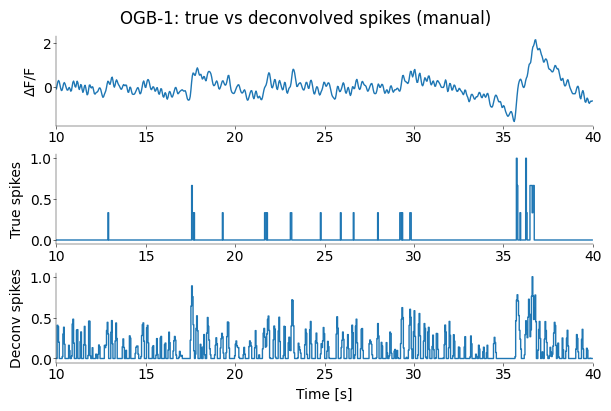

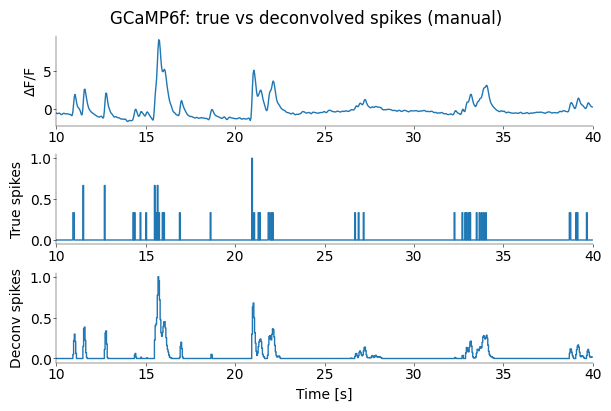

In [15]:
# ----------------------------------------------------------------------
# Compare true and deconvolved spikes rates for the OGB and GCamP cells.
# What do you notice? Why is that? (3 pts)
# ----------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell
ca_ogb = ogb_cal_filt_df.iloc[i0:i1, cell_ogb].values
spk_ogb = ogb_spk_ds.iloc[i0:i1, cell_ogb].values
spk_hat_ogb = manual_deconv_ca(ca_ogb, tau_ogb, dt)
t_seg = t[i0:i1]

# 1) Calcium trace
axs[0].plot(t_seg, ca_ogb)
axs[0].set_ylabel("ΔF/F")
axs[0].set_xlim(t_start, t_end)

# 2) True spike counts
axs[1].plot(t_seg, min_max_scale(spk_ogb), drawstyle="steps-post")
axs[1].set_ylabel("True spikes")
axs[1].set_xlim(t_start, t_end)

# 3) Deconvolved spike estimate
axs[2].plot(t_seg, min_max_scale(spk_hat_ogb), drawstyle="steps-post")
axs[2].set_ylabel("Deconv spikes")
axs[2].set_xlabel("Time [s]")
axs[2].set_xlim(t_start, t_end)

fig.suptitle("OGB-1: true vs deconvolved spikes (manual)")
plt.show()


fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# GCamp Cell
cell_gcamp = 6
ca_gc = gcamp_cal_filt_df.iloc[i0:i1, cell_gcamp].values
spk_gc = gcamp_spk_ds.iloc[i0:i1, cell_gcamp].values
spk_hat_gc = manual_deconv_ca(ca_gc, tau_gcamp, dt)

# 1) Calcium trace
axs[0].plot(t_seg, ca_gc)
axs[0].set_ylabel("ΔF/F")
axs[0].set_xlim(t_start, t_end)

# 2) True spikes
axs[1].plot(t_seg, min_max_scale(spk_gc), drawstyle="steps-post")
axs[1].set_ylabel("True spikes")
axs[1].set_xlim(t_start, t_end)

# 3) Deconvolved spikes
axs[2].plot(t_seg, min_max_scale(spk_hat_gc), drawstyle="steps-post")
axs[2].set_ylabel("Deconv spikes")
axs[2].set_xlabel("Time [s]")
axs[2].set_xlim(t_start, t_end)

fig.suptitle("GCaMP6f: true vs deconvolved spikes (manual)")
plt.show()

Our manual implementation demonstrably performs the same deconvolution as scipy's implementation. We use this as a sanity check for our manual implementation which we shall use subsequently for remainder of the exercise.

We notice that spikes obtained through deconvolution resemble the true spikes more clearly for GcaMP6f, which is explained by the faster transient and more clearly visible peaks in the GCaMP6f calcium trace. The results for OGB-1 are much more nosier, due to less clear peaks in the calcium trace, leading to possibly many false positives (i.e. wrongly as spike classified caclium trace peaks). We see clear limits to the deconvolution method, especially for slowly decaying calcium indicators.

## Task 3: Run more complex algorithm

As reviewed in the lecture, a number of more complex algorithms for inferring spikes from calcium traces have been developed. Run an implemented algorithm on the data and plot the result. There is a choice of algorithms available, for example:

* Vogelstein: [oopsi](https://github.com/liubenyuan/py-oopsi)
* Theis: [c2s](https://github.com/lucastheis/c2s)
* Friedrich: [OASIS](https://github.com/j-friedrich/OASIS)

*Grading: 3 pts*



In [16]:
# run this cell to download the oopsi.py file and put it in the same folder as this notebook
# !wget https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py
import oopsi

In [17]:
# ----------------------------------------------------------------------
# Apply one of the advanced algorithms to the OGB and GCamp Cells (1 pt)
# ----------------------------------------------------------------------

d_ogb, C_ogb_est = oopsi.fast(ca_ogb, dt=dt, iter_max=6, update=True)
d_gc, C_gc_est = oopsi.fast(ca_gc, dt=dt, iter_max=6, update=True)

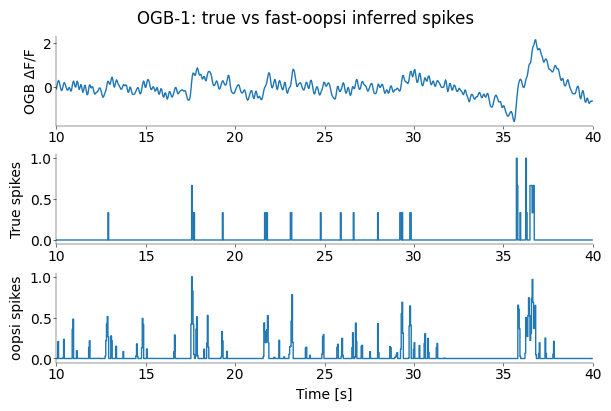

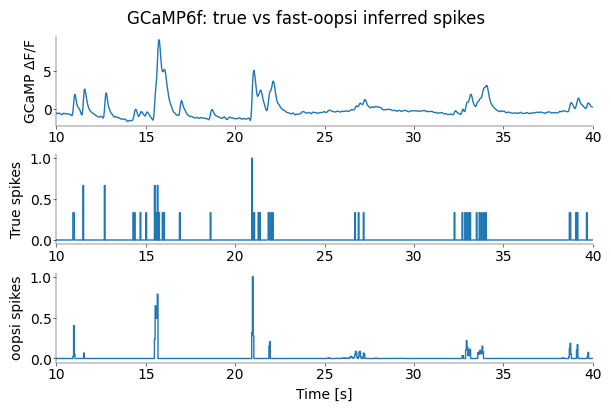

In [18]:
# -------------------------------------------------------------------------------
# Plot the results for the OGB and GCamp Cells and describe the results (1+1 pts)
# -------------------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell
axs[0].plot(t_seg, ca_ogb)
axs[0].set_ylabel("OGB ΔF/F")
axs[0].set_xlim(t_start, t_end)

axs[1].plot(
    t_seg, min_max_scale(ogb_spk_ds.iloc[i0:i1, cell_ogb]), drawstyle="steps-post"
)
axs[1].set_ylabel("True spikes")
axs[1].set_xlim(t_start, t_end)

axs[2].plot(t_seg, min_max_scale(d_ogb), drawstyle="steps-post")
axs[2].set_ylabel("oopsi spikes")
axs[2].set_xlabel("Time [s]")
axs[2].set_xlim(t_start, t_end)

fig.suptitle("OGB-1: true vs fast-oopsi inferred spikes")
plt.show()


fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

axs[0].plot(t_seg, ca_gc)
axs[0].set_ylabel("GCaMP ΔF/F")
axs[0].set_xlim(t_start, t_end)

axs[1].plot(
    t_seg, min_max_scale(gcamp_spk_ds.iloc[i0:i1, cell_gcamp]), drawstyle="steps-post"
)
axs[1].set_ylabel("True spikes")
axs[1].set_xlim(t_start, t_end)

axs[2].plot(t_seg, min_max_scale(d_gc), drawstyle="steps-post")
axs[2].set_ylabel("oopsi spikes")
axs[2].set_xlabel("Time [s]")
axs[2].set_xlim(t_start, t_end)

fig.suptitle("GCaMP6f: true vs fast-oopsi inferred spikes")
plt.show()

# GCamP Cell

Compared to our deconvolution implementation, we observe that oopsi reconstructs less false positives for the OGB-1 calcium trace. By comparison of the resulting spikes in the GCaMP6f case with the previous implementations, we observe that oopsi produces more discrete like spiking dynamics instead of continues approximations. Therefore as expected, the more complex method (oopsi) therefore seems to outperform the previous deconvolution methods qualitatively. 

## Task 4: Evaluation of algorithms

To formally evaluate the algorithms on the two datasets run the deconvolution algorithm and the more complex one on all cells and compute the correlation between true and inferred spike trains. `DataFrames` from the `pandas` package are a useful tool for aggregating data and later plotting it. Create a dataframe with columns

* algorithm
* correlation
* indicator

and enter each cell. Plot the results using `stripplot` and/or `boxplot` in the `seaborn` package. Note these functions provide useful options for formatting the
plots. See their documentation, i.e. `sns.boxplot?`.

*Grading: 5 pts*


First, evaluate on OGB data and create OGB dataframe. Then repeat for GCamp and combine the two dataframes.

TODO: when comparing the results, make sure to define the correct deconv_ca function. I defined it twice. Once with the scipy deconv and once with the manual deconv. Just need to decide which we will compare with in the code below. Can rename the manual deconv function to deconv_ca_manual if we want.

In [19]:
# ----------------------------------------------------------
# Evaluate the algorithms on the OGB and GCamp cells (2 pts)
# ----------------------------------------------------------

results_ogb = []
for cell in ogb_cal_filt_df.columns:
    ca = ogb_cal_filt_df[cell].values
    mask = ~np.isnan(ca)
    ca = ca[mask]

    sp_t = ogb_spk_ds[cell].values
    sp_t = sp_t[mask]
    # simple deconv
    sp_d = manual_deconv_ca(ca, tau_ogb, dt)
    # fast-oopsi
    sp_o, _ = oopsi.fast(ca, dt=dt, iter_max=6, update=True)
    # compute Pearson correlations
    corr_d = np.corrcoef(sp_t, sp_d)[0, 1]
    corr_o = np.corrcoef(sp_t, sp_o)[0, 1]
    results_ogb.append(
        {"algorithm": "deconv", "correlation": corr_d, "indicator": "OGB"}
    )
    results_ogb.append(
        {"algorithm": "oopsi", "correlation": corr_o, "indicator": "OGB"}
    )

results_gcamp = []
for cell in gcamp_cal_filt_df.columns:
    ca = gcamp_cal_filt_df[cell].values
    mask = ~np.isnan(ca)
    ca = ca[mask]

    sp_t = gcamp_spk_ds[cell].values
    sp_t = sp_t[mask]
    # simple deconv
    sp_d = manual_deconv_ca(ca, tau_gcamp, dt)
    # fast-oopsi
    sp_o, _ = oopsi.fast(ca, dt=dt, iter_max=6, update=True)
    # compute Pearson correlations
    corr_d = np.corrcoef(sp_t, sp_d)[0, 1]
    corr_o = np.corrcoef(sp_t, sp_o)[0, 1]
    results_gcamp.append(
        {"algorithm": "deconv", "correlation": corr_d, "indicator": "GCaMP"}
    )
    results_gcamp.append(
        {"algorithm": "oopsi", "correlation": corr_o, "indicator": "GCaMP"}
    )

In [20]:
# -------------------------------
# Construct the dataframe (1 pts)
# -------------------------------
df_ogb = pd.DataFrame(results_ogb)
df_gcamp = pd.DataFrame(results_gcamp)
df_all = pd.concat([df_ogb, df_gcamp], ignore_index=True)

Combine both dataframes. Plot the performance of each indicator and algorithm. You should only need a single plot for this.

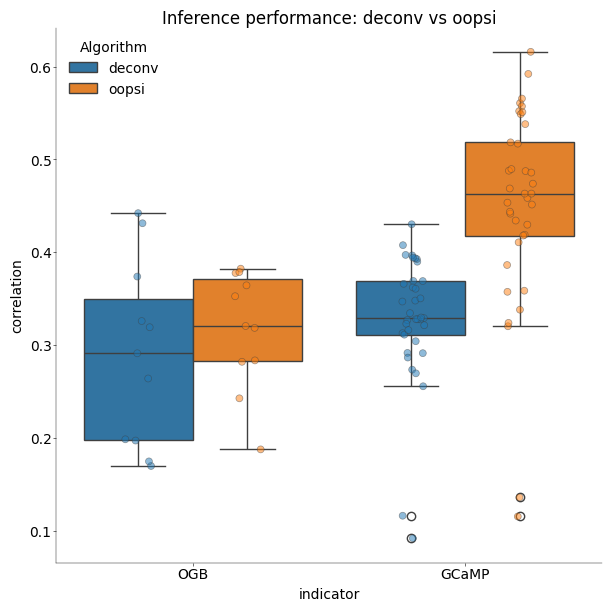

In [21]:
# ----------------------------------------------------------------------------
# Create Strip/Boxplot for both cells and algorithms Cell as described. (1 pt)
# Describe and explain the results briefly. (1 pt)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
sns.boxplot(data=df_all, x="indicator", y="correlation", hue="algorithm", ax=ax)
sns.stripplot(
    data=df_all,
    x="indicator",
    y="correlation",
    hue="algorithm",
    dodge=True,
    alpha=0.5,
    ax=ax,
    marker="o",
    linewidth=0.5,
)
# remove the duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
# keep only one set of handles/labels
n = len(df_all["algorithm"].unique())
ax.legend(handles[:n], labels[:n], title="Algorithm")
ax.set_title("Inference performance: deconv vs oopsi")
plt.show()

The results confirm our previous qualitative observations: 

- With higher correlations, OOPSI generally outperforms simple deconvolution for both indicators
- GCaMP6f generally has better spike inference performance due to its faster dynamics

On top, we find that there is considerable cell-to-cell variability in inference performance, highlighting the need to evaluate the method on enough data reflecting the diversity of biological neural dynamics.